<div style="background: linear-gradient(120deg, #1a3a5c 0%, #2d6a9f 60%, #4a9eda 100%); padding: 28px 36px; border-radius: 14px; display: flex; align-items: center; gap: 28px; box-shadow: 0 4px 18px rgba(0,0,0,0.18);">
    <img src='Figures/iteso.jpg' style="height: 110px; border-radius: 8px; background: white; padding: 6px; flex-shrink: 0; box-shadow: 0 2px 8px rgba(0,0,0,0.2);"/>
    <div style="border-left: 2px solid rgba(255,255,255,0.4); padding-left: 28px;">
        <h1 style="margin: 0 0 8px 0; color: white; font-size: 1.5em; line-height: 1.3;">Maestría en Ciencia de Datos</h1>
        <h3 style="margin: 0 0 8px 0; color: white; font-size: 1.5em; line-height: 1.3;">Ingeniería de Características</h3>
        <h3 style="margin: 0; color: rgba(255,255,255,0.8); font-weight: normal; font-size: 1.05em;">Módulo 1: Extracción de datos de diferentes fuentes</h3>
    </div>
</div>



## Propósito

La extracción es el primer paso para convertir información heterogénea en datos analizables. En este cuaderno se practican técnicas para leer archivos tabulares, texto libre, documentos jerárquicos, datos geoespaciales, páginas web e imágenes.

### Resultados de aprendizaje

- elegir una estrategia de lectura según la estructura de la fuente;
- inspeccionar tipos, dimensiones, columnas y valores antes de analizar;
- transformar datos anidados o no estructurados en tablas;
- identificar riesgos de calidad, codificación, rutas y reproducibilidad.

> **Idea central:** extraer datos no significa únicamente abrir un archivo. Significa conservar su significado, documentar los supuestos y producir una representación útil para la siguiente etapa del flujo de ciencia de datos.

```mermaid
flowchart LR
    A[Fuente original] --> B[Lectura]
    B --> C[Inspección]
    C --> D[Limpieza y transformación]
    D --> E[DataFrame o matriz]
    E --> F[Análisis y modelado]
```

## 1. Preparar el entorno y las rutas

Antes de leer una fuente conviene centralizar la carpeta de datos. Así se evita repetir rutas, se facilita mover el cuaderno y se hace más clara la procedencia de cada archivo.

En un proyecto reproducible, la ruta debe ser relativa al proyecto o construirse con `pathlib`. En los ejemplos siguientes se conserva la variable `ruta` para trabajar con los archivos didácticos del curso.


In [1]:
# Almacenamos la ruta de los archivos en una variable
ruta='Data/'

In [2]:
import os

In [3]:
os.getcwd()

'C:\\Users\\uie70742\\OneDrive - ITESO\\ITESO\\Maestría Ciencia de Datos\\Ingeniería de Características\\Ingenieria_Caracteristicas_O2026\\Módulo 1 - Extracción de datos de diferentes fuentes'

In [4]:
os.listdir(ruta)

['.ipynb_checkpoints',
 'API_SI.POV.DDAY_DS2_en_excel_v2_1930012.xls',
 'conteo_palabras.csv',
 'data.json',
 'df_tabla2.csv',
 'ejemplo.html',
 'Extracción.ipynb',
 'IFC-Subscriptions-and-Voting-Power-of-Member-Count.xml',
 'imagen.bmp',
 'tabla_1.xml',
 'tabla_2.xml',
 'texto_1.txt',
 'texto_2.txt',
 'texto_3.txt']

In [5]:
ruta_csv = os.path.join(os.getcwd(), 'Data', 'df_tabla1.csv')
ruta_csv

'C:\\Users\\uie70742\\OneDrive - ITESO\\ITESO\\Maestría Ciencia de Datos\\Ingeniería de Características\\Ingenieria_Caracteristicas_O2026\\Módulo 1 - Extracción de datos de diferentes fuentes\\Data\\df_tabla1.csv'

In [6]:
os.path.exists(ruta_csv)

False

In [7]:
try:
    ruta_csv = os.path.join(os.getcwd(), 'Data', 'df_tabla1.csv')
    df = pd.read_csv(ruta_csv)
except:
    print('No se encontró el archivo')
    None

No se encontró el archivo


In [8]:
if os.path.exists(ruta_csv):
    df = pd.read_csv(ruta_csv)
else:
    print('No se encontró el archivo')
    

No se encontró el archivo


In [9]:
os.path.dirname(ruta_csv)

'C:\\Users\\uie70742\\OneDrive - ITESO\\ITESO\\Maestría Ciencia de Datos\\Ingeniería de Características\\Ingenieria_Caracteristicas_O2026\\Módulo 1 - Extracción de datos de diferentes fuentes\\Data'

In [10]:
os.path.basename(ruta_csv)

'df_tabla1.csv'

In [11]:
os.path.splitext(os.path.basename(ruta_csv))

('df_tabla1', '.csv')

In [12]:
archivos_texto = [f for f in os.listdir(ruta) if f.endswith('.txt')]

In [13]:
ruta

'Data/'

In [14]:
for nombre in archivos_texto:
    ruta_completa = os.path.join(ruta, nombre)
    print(f'{nombre}: {os.path.getsize(ruta_completa)} bytes')

texto_1.txt: 55 bytes
texto_2.txt: 68 bytes
texto_3.txt: 1226 bytes


In [15]:
def get_data_and_sizes(ruta_base, data_type):

    return 

In [16]:
#os.walk
for carpeta_actual, subcarpetas, archivos in os.walk(ruta):
    print('Carpeta: ', carpeta_actual)
    print('Subcarpetas: ', subcarpetas)
    print('Archivos: ', archivos)



Carpeta:  Data/
Subcarpetas:  ['.ipynb_checkpoints']
Archivos:  ['API_SI.POV.DDAY_DS2_en_excel_v2_1930012.xls', 'conteo_palabras.csv', 'data.json', 'df_tabla2.csv', 'ejemplo.html', 'Extracción.ipynb', 'IFC-Subscriptions-and-Voting-Power-of-Member-Count.xml', 'imagen.bmp', 'tabla_1.xml', 'tabla_2.xml', 'texto_1.txt', 'texto_2.txt', 'texto_3.txt']
Carpeta:  Data/.ipynb_checkpoints
Subcarpetas:  []
Archivos:  ['data-checkpoint.json', 'df_tabla2-checkpoint.csv', 'IFC-Subscriptions-and-Voting-Power-of-Member-Count-checkpoint.xml', 'tabla_1-checkpoint.xml', 'tabla_2-checkpoint.xml', 'texto_1-checkpoint.txt', 'texto_2-checkpoint.txt', 'texto_3-checkpoint.txt']


# 2. Archivos Excel y CSV

Los archivos CSV y Excel representan datos tabulares: cada fila suele corresponder a una observación y cada columna a una variable. Son frecuentes en reportes, exportaciones de sistemas y conjuntos de datos pequeños o medianos.

`pandas` permite cargarlos en un `DataFrame`, una estructura que facilita filtrar, resumir y transformar datos. La lectura correcta depende de detalles como el separador, la codificación, los encabezados y los valores faltantes.

**Checklist de inspección:** después de cargar un archivo revisa `shape`, `columns`, `dtypes`, valores nulos y algunas filas. En el ejemplo se elimina `Unnamed: 0`, una columna índice que suele aparecer cuando un DataFrame se exportó sin `index=False`.


In [17]:
import pandas as pd

In [18]:
help(pd.read_csv)

Help on function read_csv in module pandas.io.parsers.readers:

read_csv(filepath_or_buffer: 'FilePath | ReadCsvBuffer[bytes] | ReadCsvBuffer[str]', *, sep: 'str | None | lib.NoDefault' = <no_default>, delimiter: 'str | None | lib.NoDefault' = None, header: "int | Sequence[int] | None | Literal['infer']" = 'infer', names: 'Sequence[Hashable] | None | lib.NoDefault' = <no_default>, index_col: 'IndexLabel | Literal[False] | None' = None, usecols: 'UsecolsArgType' = None, dtype: 'DtypeArg | None' = None, engine: 'CSVEngine | None' = None, converters: 'Mapping[Hashable, Callable] | None' = None, true_values: 'list | None' = None, false_values: 'list | None' = None, skipinitialspace: 'bool' = False, skiprows: 'list[int] | int | Callable[[Hashable], bool] | None' = None, skipfooter: 'int' = 0, nrows: 'int | None' = None, na_values: 'Hashable | Iterable[Hashable] | Mapping[Hashable, Iterable[Hashable]] | None' = None, keep_default_na: 'bool' = True, na_filter: 'bool' = True, verbose: 'bool | 

In [19]:
df_csv = pd.read_csv(ruta+'df_tabla2.csv')
print('Contenido del archivo CSV:')
print(df_csv)

Contenido del archivo CSV:
   Unnamed: 0        country  rank  year   gdppc
0           0  Liechtenstein     1  2008  141100
1           1      Singapore     4  2011   59900
2           2         Panama    68  2011   13600


In [20]:
df_csv

,Unnamed: 0,country,rank,year,gdppc
0,0,Liechtenstein,1,2008,141100
1,1,Singapore,4,2011,59900
2,2,Panama,68,2011,13600


In [21]:
df_csv

,Unnamed: 0,country,rank,year,gdppc
0,0,Liechtenstein,1,2008,141100
1,1,Singapore,4,2011,59900
2,2,Panama,68,2011,13600


In [22]:
df_csv.iloc[:,0]

0    0
1    1
2    2
Name: Unnamed: 0, dtype: int64

In [23]:
df_csv = df_csv.drop('Unnamed: 0', axis=1)
df_csv

,country,rank,year,gdppc
0,Liechtenstein,1,2008,141100
1,Singapore,4,2011,59900
2,Panama,68,2011,13600


In [24]:
df2 = pd.read_csv(ruta+'df_tabla2.csv', index_col=[0])
df2

,country,rank,year,gdppc
0,Liechtenstein,1,2008,141100
1,Singapore,4,2011,59900
2,Panama,68,2011,13600


In [25]:
df2

,country,rank,year,gdppc
0,Liechtenstein,1,2008,141100
1,Singapore,4,2011,59900
2,Panama,68,2011,13600


In [26]:
pd.read_csv(ruta+'df_tabla2.csv', index_col=[3]).drop('Unnamed: 0', axis=1)

,country,rank,gdppc
year,,,
2008,Liechtenstein,1,141100
2011,Singapore,4,59900
2011,Panama,68,13600


In [27]:
df2

,country,rank,year,gdppc
0,Liechtenstein,1,2008,141100
1,Singapore,4,2011,59900
2,Panama,68,2011,13600


In [28]:
df2.set_index('year')

,country,rank,gdppc
year,,,
2008,Liechtenstein,1,141100
2011,Singapore,4,59900
2011,Panama,68,13600


In [29]:
df2.set_index('year', inplace = True)

In [30]:
df2

,country,rank,gdppc
year,,,
2008,Liechtenstein,1,141100
2011,Singapore,4,59900
2011,Panama,68,13600


In [31]:
df2.iloc[0,1]

np.int64(1)

In [32]:
df2.loc[2008, 'country']

'Liechtenstein'

In [33]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3 entries, 2008 to 2011
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   country  3 non-null      object
 1   rank     3 non-null      int64 
 2   gdppc    3 non-null      int64 
dtypes: int64(2), object(1)
memory usage: 204.0+ bytes


In [34]:
df2.shape

(3, 3)

# 3. Archivos de texto

Los archivos de texto no siempre tienen una estructura explícita. Para extraerlos hay que determinar si sus campos están separados por tabuladores, comas, espacios u otro delimitador, o si cada columna ocupa un ancho fijo.

### De texto a `DataFrame`

La estrategia elegida debe corresponder al formato real. Si el separador cambia entre filas, hay que normalizar la fuente antes de convertirla en tabla; si el archivo contiene texto libre, conviene leerlo como una cadena y aplicar técnicas de procesamiento de lenguaje.


`pd.read_fwf` de pandas se utiliza para leer archivos de texto con columnas de ancho fijo (*fixed-width formatted lines*) y cargarlos en un DataFrame. En este formato, la posición de los caracteres define cada columna, no un separador visible.

Es útil para reportes heredados o archivos generados por sistemas antiguos. Antes de usarlo, confirma que las posiciones de inicio y fin sean consistentes en varias filas.


In [35]:
# Extracción a partir de texto separado por tabular
pd.read_fwf(ruta+'texto_2.txt',header=None) # No se puede especificar el separador

,0,1,2
0,Ana,1.0,10
1,Beto,1.1,10
2,Alfredo,6.0,9
3,Armando,5.0,9


`read_table` de pandas se utiliza para leer archivos de texto delimitados (por defecto, separados por tabulaciones) y cargarlos en un DataFrame

In [36]:
print('\t')

In [37]:
pd.read_table(ruta+'texto_2.txt',header=None) # sep='\t'

,0,1,2
0,Ana,1.0,10
1,Beto,1.1,10
2,Alfredo,6.0,9
3,Armando,5.0,9


In [38]:
# Extracción a partir de texto separado por comas
pd.read_table(ruta+'texto_1.txt',sep=',',header=None)

,0,1,2
0,Ana,1.0,10
1,Beto,1.1,10
2,Alfredo,6.0,9
3,Armando,5.0,9


In [39]:
pd.read_table(ruta+'texto_1.txt',sep=' ',header=None)

,0,1,2
0,"Ana,","1,",10
1,"Beto,","1.1,",10
2,"Alfredo,","6,",9
3,"Armando,","5,",9


In [40]:
pd.read_csv(ruta+'texto_2.txt',header=None,sep='\t') # sep=','

,0,1,2
0,Ana,1.0,10
1,Beto,1.1,10
2,Alfredo,6.0,9
3,Armando,5.0,9


In [41]:
# Conversión de archivo a variable
file=open(ruta+'texto_3.txt')     # Abrir...
texto=file.read()
file.close()                      # ...despues cerrar

In [42]:
texto

'En un lugar de la Mancha, de cuyo nombre no quiero acordarme, no ha mucho tiempo que vivÃ\xada un hidalgo de los de lanza en astillero, adarga antigua, rocÃ³n flaco y galgo corredor. Una olla de algo mÃ¡s vaca que carnero, salpicÃ³n las mÃ¡s noches, duelos y quebrantos los sÃ¡bados, lantejas los viernes, algÃºn palomino de aÃ±adidura los domingos, consumÃ\xadan las tres partes de su hacienda. El resto della concluÃ\xadan sayo de velarte, calzas de velludo para las fiestas, con sus pantuflos de lo mesmo, y los dÃ\xadas de entresemana se honraba con su vellorÃ\xad de lo mÃ¡s fino. TenÃ\xada en su casa una ama que pasaba de los cuarenta, y una sobrina que no llegaba a los veinte, y un mozo de campo y plaza, que asÃ\xad ensillaba el rocÃ\xadn como tomaba la podadera. Frisaba la edad de nuestro hidalgo con los cincuenta aÃ±os; era de complexiÃ³n recia, seco de carnes, enjuto de rostro, gran madrugador y amigo de la caza. Quieren decir que tenÃ\xada el sobrenombre de Quijada, o Quesada, que

In [43]:
# Si ocurre un error durante la ejecución, la variable file se cierra siempre:
with open(ruta+'texto_3.txt') as file:
  texto=file.read()

In [44]:
texto

'En un lugar de la Mancha, de cuyo nombre no quiero acordarme, no ha mucho tiempo que vivÃ\xada un hidalgo de los de lanza en astillero, adarga antigua, rocÃ³n flaco y galgo corredor. Una olla de algo mÃ¡s vaca que carnero, salpicÃ³n las mÃ¡s noches, duelos y quebrantos los sÃ¡bados, lantejas los viernes, algÃºn palomino de aÃ±adidura los domingos, consumÃ\xadan las tres partes de su hacienda. El resto della concluÃ\xadan sayo de velarte, calzas de velludo para las fiestas, con sus pantuflos de lo mesmo, y los dÃ\xadas de entresemana se honraba con su vellorÃ\xad de lo mÃ¡s fino. TenÃ\xada en su casa una ama que pasaba de los cuarenta, y una sobrina que no llegaba a los veinte, y un mozo de campo y plaza, que asÃ\xad ensillaba el rocÃ\xadn como tomaba la podadera. Frisaba la edad de nuestro hidalgo con los cincuenta aÃ±os; era de complexiÃ³n recia, seco de carnes, enjuto de rostro, gran madrugador y amigo de la caza. Quieren decir que tenÃ\xada el sobrenombre de Quijada, o Quesada, que

In [45]:
# Separamos cada palabra de la variable de texto
texto.split()

['En',
 'un',
 'lugar',
 'de',
 'la',
 'Mancha,',
 'de',
 'cuyo',
 'nombre',
 'no',
 'quiero',
 'acordarme,',
 'no',
 'ha',
 'mucho',
 'tiempo',
 'que',
 'vivÃ\xada',
 'un',
 'hidalgo',
 'de',
 'los',
 'de',
 'lanza',
 'en',
 'astillero,',
 'adarga',
 'antigua,',
 'rocÃ³n',
 'flaco',
 'y',
 'galgo',
 'corredor.',
 'Una',
 'olla',
 'de',
 'algo',
 'mÃ¡s',
 'vaca',
 'que',
 'carnero,',
 'salpicÃ³n',
 'las',
 'mÃ¡s',
 'noches,',
 'duelos',
 'y',
 'quebrantos',
 'los',
 'sÃ¡bados,',
 'lantejas',
 'los',
 'viernes,',
 'algÃºn',
 'palomino',
 'de',
 'aÃ±adidura',
 'los',
 'domingos,',
 'consumÃ\xadan',
 'las',
 'tres',
 'partes',
 'de',
 'su',
 'hacienda.',
 'El',
 'resto',
 'della',
 'concluÃ\xadan',
 'sayo',
 'de',
 'velarte,',
 'calzas',
 'de',
 'velludo',
 'para',
 'las',
 'fiestas,',
 'con',
 'sus',
 'pantuflos',
 'de',
 'lo',
 'mesmo,',
 'y',
 'los',
 'dÃ\xadas',
 'de',
 'entresemana',
 'se',
 'honraba',
 'con',
 'su',
 'vellorÃ\xad',
 'de',
 'lo',
 'mÃ¡s',
 'fino.',
 'TenÃ\xada',
 'en

In [46]:
texto.split?

Signature: texto.split(sep=None, maxsplit=-1)
Docstring:
Return a list of the substrings in the string, using sep as the separator string.

  sep
    The separator used to split the string.

    When set to None (the default value), will split on any whitespace
    character (including \\n \\r \\t \\f and spaces) and will discard
    empty strings from the result.
  maxsplit
    Maximum number of splits (starting from the left).
    -1 (the default value) means no limit.

Note, str.split() is mainly useful for data that has been intentionally
delimited.  With natural text that includes punctuation, consider using
the regular expression module.
Type:      builtin_function_or_method

In [47]:
with open(ruta+'texto_3.txt', encoding='utf-8') as file:
  texto=file.read()

In [48]:
texto

'En un lugar de la Mancha, de cuyo nombre no quiero acordarme, no ha mucho tiempo que vivía un hidalgo de los de lanza en astillero, adarga antigua, rocón flaco y galgo corredor. Una olla de algo más vaca que carnero, salpicón las más noches, duelos y quebrantos los sábados, lantejas los viernes, algún palomino de añadidura los domingos, consumían las tres partes de su hacienda. El resto della concluían sayo de velarte, calzas de velludo para las fiestas, con sus pantuflos de lo mesmo, y los días de entresemana se honraba con su vellorí de lo más fino. Tenía en su casa una ama que pasaba de los cuarenta, y una sobrina que no llegaba a los veinte, y un mozo de campo y plaza, que así ensillaba el rocín como tomaba la podadera. Frisaba la edad de nuestro hidalgo con los cincuenta años; era de complexión recia, seco de carnes, enjuto de rostro, gran madrugador y amigo de la caza. Quieren decir que tenía el sobrenombre de Quijada, o Quesada, que en esto hay alguna diferencia en los autores 

In [49]:
#Natural Lenguage Processing (BOW)
texto.lower().split()

['en',
 'un',
 'lugar',
 'de',
 'la',
 'mancha,',
 'de',
 'cuyo',
 'nombre',
 'no',
 'quiero',
 'acordarme,',
 'no',
 'ha',
 'mucho',
 'tiempo',
 'que',
 'vivía',
 'un',
 'hidalgo',
 'de',
 'los',
 'de',
 'lanza',
 'en',
 'astillero,',
 'adarga',
 'antigua,',
 'rocón',
 'flaco',
 'y',
 'galgo',
 'corredor.',
 'una',
 'olla',
 'de',
 'algo',
 'más',
 'vaca',
 'que',
 'carnero,',
 'salpicón',
 'las',
 'más',
 'noches,',
 'duelos',
 'y',
 'quebrantos',
 'los',
 'sábados,',
 'lantejas',
 'los',
 'viernes,',
 'algún',
 'palomino',
 'de',
 'añadidura',
 'los',
 'domingos,',
 'consumían',
 'las',
 'tres',
 'partes',
 'de',
 'su',
 'hacienda.',
 'el',
 'resto',
 'della',
 'concluían',
 'sayo',
 'de',
 'velarte,',
 'calzas',
 'de',
 'velludo',
 'para',
 'las',
 'fiestas,',
 'con',
 'sus',
 'pantuflos',
 'de',
 'lo',
 'mesmo,',
 'y',
 'los',
 'días',
 'de',
 'entresemana',
 'se',
 'honraba',
 'con',
 'su',
 'vellorí',
 'de',
 'lo',
 'más',
 'fino.',
 'tenía',
 'en',
 'su',
 'casa',
 'una',
 'ama

In [50]:
voc = set(texto.lower().split())
voc

{'a',
 'acordarme,',
 'adarga',
 'algo',
 'alguna',
 'algún',
 'ama',
 'amigo',
 'antigua,',
 'astillero,',
 'así',
 'aunque',
 'autores',
 'añadidura',
 'años;',
 'basta',
 'calzas',
 'campo',
 'carnero,',
 'carnes,',
 'casa',
 'caso',
 'caza.',
 'cincuenta',
 'como',
 'complexión',
 'con',
 'concluían',
 'conjeturas',
 'consumían',
 'corredor.',
 'cuarenta,',
 'cuento:',
 'cuyo',
 'de',
 'decir',
 'deja',
 'della',
 'deste',
 'diferencia',
 'domingos,',
 'duelos',
 'dél',
 'días',
 'edad',
 'el',
 'en',
 'enjuto',
 'ensillaba',
 'entender',
 'entresemana',
 'era',
 'escriben;',
 'esto',
 'fiestas,',
 'fino.',
 'flaco',
 'frisaba',
 'galgo',
 'gran',
 'ha',
 'hacienda.',
 'hay',
 'hidalgo',
 'honraba',
 'importa',
 'la',
 'lantejas',
 'lanza',
 'las',
 'llamaba',
 'llegaba',
 'lo',
 'los',
 'lugar',
 'madrugador',
 'mancha,',
 'mesmo,',
 'mozo',
 'mucho',
 'más',
 'narración',
 'no',
 'noches,',
 'nombre',
 'nuestro',
 'o',
 'olla',
 'palomino',
 'pantuflos',
 'para',
 'partes',
 'pas

In [51]:
len(voc)

137

### 3.1 Expresiones regulares

Las **expresiones regulares** (*regex*) describen patrones de texto. Son apropiadas cuando la fuente no tiene una estructura tabular, pero sí reglas repetibles: correos, fechas, identificadores o códigos.

El flujo habitual es: definir el patrón, probarlo con ejemplos representativos, extraer coincidencias y validar los casos que no coincidan. Una regex demasiado general puede capturar datos incorrectos; una demasiado estricta puede omitir variaciones válidas.


Las **expresiones regulares** (regex) son patrones que se utilizan para buscar, extraer o manipular texto de manera flexible y eficiente. Permiten identificar cadenas de texto que cumplen ciertas reglas, como correos electrónicos, números de teléfono, palabras específicas, etc.

##### ¿Cómo se usan en Python?

En Python, se utiliza el módulo `re` para trabajar con expresiones regulares. Algunas funciones comunes son:

- `re.search()`: busca un patrón en cualquier posición y devuelve la primera coincidencia.
- `re.match()`: comprueba la coincidencia desde el inicio de la cadena.
- `re.findall()`: devuelve todas las coincidencias como una lista.
- `re.split()`: divide el texto usando el patrón como separador.
- `re.sub()`: reemplaza coincidencias por otro texto.

##### ¿Cómo definir patrones en regex?

- Los patrones se definen como cadenas de texto; el prefijo `r` evita que Python interprete algunas barras invertidas antes que regex.
- Algunos caracteres especiales:
  - `.`: cualquier carácter excepto salto de línea
  - `\d`: un dígito (0-9)
  - `\w`: un carácter alfanumérico o guion bajo
  - `\s`: un espacio en blanco
  - `*`: cero o más repeticiones
  - `+`: una o más repeticiones
  - `?`: cero o una repetición
  - `^`: inicio de línea
  - `$`: fin de línea
  - `[abc]`: cualquier carácter a, b o c
  - `( )`: agrupación y captura

> **Lectura del ejemplo:** `\w+@\w+\.\w+` busca una estructura simple de correo. Es útil para aprender, pero no pretende validar todas las direcciones permitidas por los estándares de correo.


###### Ejemplo: Correos electrónicos

In [52]:
import re

texto_correo = "Mi correo es gdesirena@iteso.mx pero anteriormente usaba gdesirena@gmail.com"
patron = r"\w+@\w+\.\w+"  # patrón para un correo electrónico

resultado = re.search(patron, texto_correo)
if resultado:
    print("Correo encontrado:", resultado.group())

Correo encontrado: gdesirena@iteso.mx


In [53]:
correos = re.findall(patron, texto_correo) #Encuentra todos los correos en texto_correo
correos

['gdesirena@iteso.mx', 'gdesirena@gmail.com']

In [54]:
df_correos = pd.DataFrame({'correo': correos})
df_correos

,correo
0,gdesirena@iteso.mx
1,gdesirena@gmail.com


In [55]:
dominios = re.findall(r'@([\w\.-]+)', texto_correo) #captura el dominio después del @
print('Dominios encontrados:', dominios)

Dominios encontrados: ['iteso.mx', 'gmail.com']


In [56]:
texto_fechas = 'algunas fechas importantes son 15/09/2023 y 01/01/2024.' 
fechas = re.findall(r'\b\d{2}/\d{2}/\d{4}\b', texto_fechas) #Encuentra todas las fechas
print('Fechas encontradas:', fechas)

Fechas encontradas: ['15/09/2023', '01/01/2024']


###### Ejemplo: Conteo de palabras usando regex

In [57]:
#re.split?

In [58]:
L=re.split(r'\W',texto)
L

['En',
 'un',
 'lugar',
 'de',
 'la',
 'Mancha',
 '',
 'de',
 'cuyo',
 'nombre',
 'no',
 'quiero',
 'acordarme',
 '',
 'no',
 'ha',
 'mucho',
 'tiempo',
 'que',
 'vivía',
 'un',
 'hidalgo',
 'de',
 'los',
 'de',
 'lanza',
 'en',
 'astillero',
 '',
 'adarga',
 'antigua',
 '',
 'rocón',
 'flaco',
 'y',
 'galgo',
 'corredor',
 '',
 'Una',
 'olla',
 'de',
 'algo',
 'más',
 'vaca',
 'que',
 'carnero',
 '',
 'salpicón',
 'las',
 'más',
 'noches',
 '',
 'duelos',
 'y',
 'quebrantos',
 'los',
 'sábados',
 '',
 'lantejas',
 'los',
 'viernes',
 '',
 'algún',
 'palomino',
 'de',
 'añadidura',
 'los',
 'domingos',
 '',
 'consumían',
 'las',
 'tres',
 'partes',
 'de',
 'su',
 'hacienda',
 '',
 'El',
 'resto',
 'della',
 'concluían',
 'sayo',
 'de',
 'velarte',
 '',
 'calzas',
 'de',
 'velludo',
 'para',
 'las',
 'fiestas',
 '',
 'con',
 'sus',
 'pantuflos',
 'de',
 'lo',
 'mesmo',
 '',
 'y',
 'los',
 'días',
 'de',
 'entresemana',
 'se',
 'honraba',
 'con',
 'su',
 'vellorí',
 'de',
 'lo',
 'más',


In [59]:
# Convertimos la lista a set
S=set(L)
S.discard('')
S

{'El',
 'En',
 'Frisaba',
 'Mancha',
 'Pero',
 'Quesada',
 'Quieren',
 'Quijada',
 'Quijana',
 'Tenía',
 'Una',
 'a',
 'acordarme',
 'adarga',
 'algo',
 'alguna',
 'algún',
 'ama',
 'amigo',
 'antigua',
 'astillero',
 'así',
 'aunque',
 'autores',
 'añadidura',
 'años',
 'basta',
 'calzas',
 'campo',
 'carnero',
 'carnes',
 'casa',
 'caso',
 'caza',
 'cincuenta',
 'como',
 'complexión',
 'con',
 'concluían',
 'conjeturas',
 'consumían',
 'corredor',
 'cuarenta',
 'cuento',
 'cuyo',
 'de',
 'decir',
 'deja',
 'della',
 'deste',
 'diferencia',
 'domingos',
 'duelos',
 'dél',
 'días',
 'edad',
 'el',
 'en',
 'enjuto',
 'ensillaba',
 'entender',
 'entresemana',
 'era',
 'escriben',
 'esto',
 'fiestas',
 'fino',
 'flaco',
 'galgo',
 'gran',
 'ha',
 'hacienda',
 'hay',
 'hidalgo',
 'honraba',
 'importa',
 'la',
 'lantejas',
 'lanza',
 'las',
 'llamaba',
 'llegaba',
 'lo',
 'los',
 'lugar',
 'madrugador',
 'mesmo',
 'mozo',
 'mucho',
 'más',
 'narración',
 'no',
 'noches',
 'nombre',
 'nuestr

In [60]:
# Buscamos las palabras no repetidas del set en la variable de texto para poderlas contar
re.findall?

Signature: re.findall(pattern, string, flags=0)
Docstring:
Return a list of all non-overlapping matches in the string.

If one or more capturing groups are present in the pattern, return
a list of groups; this will be a list of tuples if the pattern
has more than one group.

Empty matches are included in the result.
File:      c:\users\uie70742\.conda\envs\ic_curso_2026\lib\re.py
Type:      function

In [61]:
# En, en

In [62]:
re.findall('en',texto,flags=re.I)

['En',
 'en',
 'en',
 'en',
 'en',
 'en',
 'en',
 'en',
 'en',
 'en',
 'en',
 'en',
 'en',
 'en',
 'en',
 'en',
 'en',
 'en',
 'en',
 'en',
 'en']

In [63]:
d={}
for palabra in S:
    d[palabra]=len(re.findall(palabra,texto,flags=re.I))
d

{'consumían': 1,
 'cuarenta': 1,
 'lugar': 1,
 'veinte': 1,
 'Pero': 1,
 'salga': 1,
 'pasaba': 1,
 'vaca': 1,
 'nuestro': 2,
 'rostro': 1,
 'carnero': 1,
 'era': 2,
 'un': 10,
 'complexión': 1,
 'seco': 1,
 'poco': 1,
 'caso': 1,
 'casa': 1,
 'nombre': 2,
 'rocón': 1,
 'diferencia': 1,
 'basta': 1,
 'años': 1,
 'Una': 4,
 'Quijana': 1,
 'fino': 1,
 'salpicón': 1,
 'verosímiles': 1,
 'campo': 1,
 'de': 27,
 'adarga': 1,
 'a': 131,
 'acordarme': 1,
 'lanza': 1,
 'fiestas': 1,
 'sobrina': 1,
 'que': 13,
 'añadidura': 1,
 'Quesada': 1,
 'mozo': 1,
 'mucho': 1,
 'honraba': 1,
 'astillero': 1,
 'podadera': 1,
 'caza': 1,
 'autores': 1,
 'o': 88,
 'olla': 1,
 'concluían': 1,
 'días': 1,
 'della': 1,
 'como': 1,
 'una': 4,
 'las': 3,
 'Tenía': 2,
 'más': 3,
 'decir': 1,
 'cuyo': 1,
 'palomino': 1,
 'esto': 3,
 'cincuenta': 1,
 'por': 2,
 'tiempo': 1,
 'lo': 15,
 'velarte': 1,
 'flaco': 1,
 'tres': 2,
 'hidalgo': 2,
 'narración': 1,
 'partes': 1,
 'punto': 1,
 'antigua': 1,
 'madrugador': 1,
 

In [64]:
d.items()

dict_items([('consumían', 1), ('cuarenta', 1), ('lugar', 1), ('veinte', 1), ('Pero', 1), ('salga', 1), ('pasaba', 1), ('vaca', 1), ('nuestro', 2), ('rostro', 1), ('carnero', 1), ('era', 2), ('un', 10), ('complexión', 1), ('seco', 1), ('poco', 1), ('caso', 1), ('casa', 1), ('nombre', 2), ('rocón', 1), ('diferencia', 1), ('basta', 1), ('años', 1), ('Una', 4), ('Quijana', 1), ('fino', 1), ('salpicón', 1), ('verosímiles', 1), ('campo', 1), ('de', 27), ('adarga', 1), ('a', 131), ('acordarme', 1), ('lanza', 1), ('fiestas', 1), ('sobrina', 1), ('que', 13), ('añadidura', 1), ('Quesada', 1), ('mozo', 1), ('mucho', 1), ('honraba', 1), ('astillero', 1), ('podadera', 1), ('caza', 1), ('autores', 1), ('o', 88), ('olla', 1), ('concluían', 1), ('días', 1), ('della', 1), ('como', 1), ('una', 4), ('las', 3), ('Tenía', 2), ('más', 3), ('decir', 1), ('cuyo', 1), ('palomino', 1), ('esto', 3), ('cincuenta', 1), ('por', 2), ('tiempo', 1), ('lo', 15), ('velarte', 1), ('flaco', 1), ('tres', 2), ('hidalgo', 2)

In [65]:
df=pd.DataFrame(d.items(),columns=['Palabra','No.'])

In [66]:
df.head()

,Palabra,No.
0,consumían,1
1,cuarenta,1
2,lugar,1
3,veinte,1
4,Pero,1


https://regex101.com/

# 4. Archivos Excel

Excel puede contener varias hojas, fórmulas, índices y celdas de presentación. Al extraer datos, distingue la hoja que contiene la tabla de las filas de título o notas que sirven para lectura humana.

`pd.read_excel` es conveniente para leer directamente una hoja. `ExcelFile` resulta útil cuando se desea inspeccionar o reutilizar un libro con varias hojas sin abrirlo repetidamente.

> **Buenas prácticas:** registra el nombre de la hoja, comprueba los encabezados y convierte explícitamente fechas y números cuando Excel los haya interpretado de forma ambigua.


In [67]:
# A partir de la función
pd.read_excel(ruta+'API_SI.POV.DDAY_DS2_en_excel_v2_1930012.xls')

,Data Source,World Development Indicators,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 55,Unnamed: 56,Unnamed: 57,Unnamed: 58,Unnamed: 59,Unnamed: 60,Unnamed: 61,Unnamed: 62,Unnamed: 63,Unnamed: 64
0,Last Updated Date,2020-12-16 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Country Name,Country Code,Indicator Name,Indicator Code,1960.0,1961.0,1962.0,1963.0,1964.0,1965.0,...,2011.0,2012.0,2013.0,2014.0,2015.0,2016.0,2017.0,2018.0,2019.0,2020.0
3,Aruba,ABW,Poverty headcount ratio at $1.90 a day (2011 P...,SI.POV.DDAY,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,AFG,Poverty headcount ratio at $1.90 a day (2011 P...,SI.POV.DDAY,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
262,Kosovo,XKX,Poverty headcount ratio at $1.90 a day (2011 P...,SI.POV.DDAY,NaN,NaN,NaN,NaN,NaN,NaN,...,1.7,0.6,0.3,1.0,0.7,0.8,0.4,NaN,NaN,NaN
263,"Yemen, Rep.",YEM,Poverty headcount ratio at $1.90 a day (2011 P...,SI.POV.DDAY,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,18.3,NaN,NaN,NaN,NaN,NaN,NaN
264,South Africa,ZAF,Poverty headcount ratio at $1.90 a day (2011 P...,SI.POV.DDAY,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,18.7,NaN,NaN,NaN,NaN,NaN,NaN
265,Zambia,ZMB,Poverty headcount ratio at $1.90 a day (2011 P...,SI.POV.DDAY,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,58.7,NaN,NaN,NaN,NaN,NaN


In [68]:
# Importamos la clase ExcelFile
from pandas import ExcelFile

In [69]:
# A partir de la clase
obj=ExcelFile(ruta+'API_SI.POV.DDAY_DS2_en_excel_v2_1930012.xls')
obj.parse() # Importa la primera página

,Data Source,World Development Indicators,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 55,Unnamed: 56,Unnamed: 57,Unnamed: 58,Unnamed: 59,Unnamed: 60,Unnamed: 61,Unnamed: 62,Unnamed: 63,Unnamed: 64
0,Last Updated Date,2020-12-16 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Country Name,Country Code,Indicator Name,Indicator Code,1960.0,1961.0,1962.0,1963.0,1964.0,1965.0,...,2011.0,2012.0,2013.0,2014.0,2015.0,2016.0,2017.0,2018.0,2019.0,2020.0
3,Aruba,ABW,Poverty headcount ratio at $1.90 a day (2011 P...,SI.POV.DDAY,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,AFG,Poverty headcount ratio at $1.90 a day (2011 P...,SI.POV.DDAY,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
262,Kosovo,XKX,Poverty headcount ratio at $1.90 a day (2011 P...,SI.POV.DDAY,NaN,NaN,NaN,NaN,NaN,NaN,...,1.7,0.6,0.3,1.0,0.7,0.8,0.4,NaN,NaN,NaN
263,"Yemen, Rep.",YEM,Poverty headcount ratio at $1.90 a day (2011 P...,SI.POV.DDAY,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,18.3,NaN,NaN,NaN,NaN,NaN,NaN
264,South Africa,ZAF,Poverty headcount ratio at $1.90 a day (2011 P...,SI.POV.DDAY,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,18.7,NaN,NaN,NaN,NaN,NaN,NaN
265,Zambia,ZMB,Poverty headcount ratio at $1.90 a day (2011 P...,SI.POV.DDAY,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,58.7,NaN,NaN,NaN,NaN,NaN


In [70]:
help(obj.parse)

Help on method parse in module pandas.io.excel._base:

parse(sheet_name: 'str | int | list[int] | list[str] | None' = 0, header: 'int | Sequence[int] | None' = 0, names: 'SequenceNotStr[Hashable] | range | None' = None, index_col: 'int | Sequence[int] | None' = None, usecols=None, converters=None, true_values: 'Iterable[Hashable] | None' = None, false_values: 'Iterable[Hashable] | None' = None, skiprows: 'Sequence[int] | int | Callable[[int], object] | None' = None, nrows: 'int | None' = None, na_values=None, parse_dates: 'list | dict | bool' = False, date_parser: 'Callable | lib.NoDefault' = <no_default>, date_format: 'str | dict[Hashable, str] | None' = None, thousands: 'str | None' = None, comment: 'str | None' = None, skipfooter: 'int' = 0, dtype_backend: 'DtypeBackend | lib.NoDefault' = <no_default>, **kwds) -> 'DataFrame | dict[str, DataFrame] | dict[int, DataFrame]' method of pandas.io.excel._base.ExcelFile instance
    Parse specified sheet(s) into a DataFrame.
    
    Equival

In [71]:
obj.sheet_names

['Data', 'Metadata - Countries', 'Metadata - Indicators']

In [72]:
df_data = obj.parse('Data', header=3)
df_data

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
0,Aruba,ABW,Poverty headcount ratio at $1.90 a day (2011 P...,SI.POV.DDAY,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,AFG,Poverty headcount ratio at $1.90 a day (2011 P...,SI.POV.DDAY,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Angola,AGO,Poverty headcount ratio at $1.90 a day (2011 P...,SI.POV.DDAY,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,51.8,NaN,NaN
3,Albania,ALB,Poverty headcount ratio at $1.90 a day (2011 P...,SI.POV.DDAY,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.8,NaN,1.6,1.1,0.9,1.3,NaN,NaN,NaN
4,Andorra,AND,Poverty headcount ratio at $1.90 a day (2011 P...,SI.POV.DDAY,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
259,Kosovo,XKX,Poverty headcount ratio at $1.90 a day (2011 P...,SI.POV.DDAY,NaN,NaN,NaN,NaN,NaN,NaN,...,1.7,0.6,0.3,1.0,0.7,0.8,0.4,NaN,NaN,NaN
260,"Yemen, Rep.",YEM,Poverty headcount ratio at $1.90 a day (2011 P...,SI.POV.DDAY,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,18.3,NaN,NaN,NaN,NaN,NaN,NaN
261,South Africa,ZAF,Poverty headcount ratio at $1.90 a day (2011 P...,SI.POV.DDAY,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,18.7,NaN,NaN,NaN,NaN,NaN,NaN
262,Zambia,ZMB,Poverty headcount ratio at $1.90 a day (2011 P...,SI.POV.DDAY,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,58.7,NaN,NaN,NaN,NaN,NaN


In [73]:
df_paises = obj.parse('Metadata - Countries')
df_paises

,Country Code,Region,IncomeGroup,SpecialNotes,TableName
0,ABW,Latin America & Caribbean,High income,NaN,Aruba
1,AFG,South Asia,Low income,NaN,Afghanistan
2,AGO,Sub-Saharan Africa,Lower middle income,NaN,Angola
3,ALB,Europe & Central Asia,Upper middle income,NaN,Albania
4,AND,Europe & Central Asia,High income,NaN,Andorra
...,...,...,...,...,...
258,XKX,Europe & Central Asia,Upper middle income,NaN,Kosovo
259,YEM,Middle East & North Africa,Low income,NaN,"Yemen, Rep."
260,ZAF,Sub-Saharan Africa,Upper middle income,Fiscal year end: March 31; reporting period fo...,South Africa
261,ZMB,Sub-Saharan Africa,Lower middle income,National accounts data were rebased to reflect...,Zambia


In [74]:
df_dict = {}
for data in obj.sheet_names:
    df_dict[data] = obj.parse(data)

In [75]:
df_dict['Data']

,Data Source,World Development Indicators,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 55,Unnamed: 56,Unnamed: 57,Unnamed: 58,Unnamed: 59,Unnamed: 60,Unnamed: 61,Unnamed: 62,Unnamed: 63,Unnamed: 64
0,Last Updated Date,2020-12-16 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Country Name,Country Code,Indicator Name,Indicator Code,1960.0,1961.0,1962.0,1963.0,1964.0,1965.0,...,2011.0,2012.0,2013.0,2014.0,2015.0,2016.0,2017.0,2018.0,2019.0,2020.0
3,Aruba,ABW,Poverty headcount ratio at $1.90 a day (2011 P...,SI.POV.DDAY,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,AFG,Poverty headcount ratio at $1.90 a day (2011 P...,SI.POV.DDAY,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
262,Kosovo,XKX,Poverty headcount ratio at $1.90 a day (2011 P...,SI.POV.DDAY,NaN,NaN,NaN,NaN,NaN,NaN,...,1.7,0.6,0.3,1.0,0.7,0.8,0.4,NaN,NaN,NaN
263,"Yemen, Rep.",YEM,Poverty headcount ratio at $1.90 a day (2011 P...,SI.POV.DDAY,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,18.3,NaN,NaN,NaN,NaN,NaN,NaN
264,South Africa,ZAF,Poverty headcount ratio at $1.90 a day (2011 P...,SI.POV.DDAY,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,18.7,NaN,NaN,NaN,NaN,NaN,NaN
265,Zambia,ZMB,Poverty headcount ratio at $1.90 a day (2011 P...,SI.POV.DDAY,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,58.7,NaN,NaN,NaN,NaN,NaN


# 5. Archivos JSON

JSON representa datos mediante pares `clave: valor`, listas y objetos anidados. Es muy habitual en APIs, configuraciones y registros de aplicaciones porque conserva mejor la estructura que una tabla plana.

El proceso tiene dos etapas: `json.load` o `json.loads` convierte el contenido a diccionarios y listas de Python; después, `json_normalize` ayuda a convertir objetos repetidos o anidados en columnas de un DataFrame. No todos los JSON tienen la misma forma, por lo que primero conviene inspeccionar sus claves y niveles.


El formato JSON (JavaScript Object Notation) es ampliamente utilizado para el intercambio de datos, especialmente en aplicaciones web y APIs. Python incluye la librería estándar `json` para leer y manipular archivos JSON.

In [76]:
import json

json_data = '{"personas": [{"nombre": "Ana", "edad": 23}, {"nombre": "Luis", "edad": 31}]}'
data = json.loads(json_data)
print('Personas extraídas del archivo JSON:')
for persona in data['personas']:
    print(f'Nombre: {persona["nombre"]}, Edad: {persona["edad"]}')

Personas extraídas del archivo JSON:
Nombre: Ana, Edad: 23
Nombre: Luis, Edad: 31


In [77]:
from pandas import json_normalize

with open('Data/data.json') as jsonfile:
    jsondata = json.load(jsonfile)
    
df_json = json_normalize(jsondata['data'])
df_json

,_id,categories,isActive,imageUrl,barcode,isFmcg,itemName,mrp,_created_at,_updated_at
0,OzE5vaa3p7,"[{'__type': 'Pointer', 'className': 'Category'...",True,https://firebasestorage.googleapis.com/v0/b/sh...,8908001921015,True,Anil puttu flour 500g,58,2016-10-02T13:49:03.281Z,2017-02-22T08:48:09.548Z
1,ENPCL8ph1p,"[{'__type': 'Pointer', 'className': 'Category'...",True,https://firebasestorage.googleapis.com/v0/b/ki...,8901725181222,True,"Yippee Magic Masala Noodles, 70 G",12,2016-10-02T13:49:03.284Z,2017-02-22T08:48:09.074Z


In [78]:
df_json['categories'][0]


[{'__type': 'Pointer', 'className': 'Category', 'objectId': 'nebCwWd2Fr'}]

In [93]:
jsondata.keys()

dict_keys(['data'])

In [96]:
df_cat = json_normalize(jsondata['data'], record_path= 'categories', meta = ['_id'])
df_cat

,__type,className,objectId,_id
0,Pointer,Category,nebCwWd2Fr,OzE5vaa3p7
1,Pointer,Category,B4nZeUHmVK,ENPCL8ph1p


# 6. Archivos XML

XML organiza la información como un árbol de elementos. Cada nodo puede tener una etiqueta, atributos, texto y nodos hijos. Esta jerarquía permite representar relaciones complejas, aunque requiere recorrer el árbol para llegar a los valores.

En los ejemplos se usan dos enfoques: `find`/`findall` para rutas conocidas y recorridos anidados cuando se necesita explorar la estructura. Al convertir XML a tabla hay que decidir qué nodo representa una fila y cómo tratar los elementos que faltan o se repiten.


El formato XML es común para el intercambio de datos estructurados. Python ofrece la librería estándar `xml.etree.ElementTree` para analizar y extraer información de archivos XML.

In [79]:
import xml.etree.ElementTree as ET

In [80]:
xml_data = '''
<personas>
  <persona>
    <nombre>Ana</nombre>
    <edad>23</edad>
  </persona>
  <persona>
    <nombre>Luis</nombre>
    <edad>31</edad>
  </persona>
</personas>
'''

In [81]:
root = ET.fromstring(xml_data)
print('Personas extraídas del archivo XML:')
for persona in root.findall('persona'):
    nombre = persona.find('nombre').text
    edad = persona.find('edad').text
    print(f'Nombre: {nombre}, Edad: {edad}')

Personas extraídas del archivo XML:
Nombre: Ana, Edad: 23
Nombre: Luis, Edad: 31


###### Ejemplo con tabla_1.xml


In [82]:
archivo_1=ET.parse(ruta+'tabla_1.xml')
raiz=archivo_1.getroot()

In [83]:
raiz

<Element 'data' at 0x00000254083F6A20>

In [84]:
for nodo in raiz:
    print(nodo.attrib,nodo.text,nodo.tag)
    for sn in nodo:
        print(sn.attrib,sn.text,sn.tag)

{'name': 'Liechtenstein'} 
         country
{} 1 rank
{} 2008 year
{} 141100 gdppc
{'name': 'Singapore'} 
         country
{} 4 rank
{} 2011 year
{} 59900 gdppc
{'name': 'Panama'} 
         country
{} 68 rank
{} 2011 year
{} 13600 gdppc


In [85]:
archivo_2=ET.parse(ruta+'tabla_2.xml')
root=archivo_2.getroot()
for nodo in root:
    print(nodo.tag,nodo.attrib,nodo.text)

documents {'count': 'N'} 
        


In [86]:
for nodo in root:
    for subn in nodo:
        print(subn.tag,subn.attrib,subn.text)

document {'KEY': 'e95a9a6c790ecb95e46cf15bee517651', 'web': 'www.ubm/doc004.com'} Nevertheless, high and based on experience, fluctuating throughput levels contradict high reliability.

        
document {'KEY': 'bc360cfbafc39970587547215162f0db', 'web': 'www.ubm/doc006.com'} As long as the production is not conducted on the basis of concrete customer orders, the companies objectives

        
document {'KEY': '19e71144c50a8b9160b3f0955e906fce', 'web': 'www.ubm/doc005.com'} Many companies today, in different fields of operations and sizes, have access to a vast amount of data which was not available only a couple of years ago.

        
document {'KEY': '21d4af9021a174f61b884606c74d9e42', 'web': 'www.ubm/doc002.com'} A famous example of a successful prediction is by the German astronomer Johann Gottfried Galle

        
document {'KEY': '28a45eb2460899763d709ca00ddbb665', 'web': 'www.ubm/doc001.com'} A more recent example of the same kind is the prediction of the Higgs boson by Francoi

In [87]:
#Extraer los datos de tabla_1.xml
d={}
for nodo in raiz:
    d[nodo.tag]=[]
for nodo in raiz:
    d[nodo.tag].append(nodo.attrib['name'])
for nodo in raiz:
    for sn in nodo:
        d[sn.tag]=[]
for nodo in raiz:
    for sn in nodo:
        d[sn.tag].append(sn.text)
d

{'country': ['Liechtenstein', 'Singapore', 'Panama'],
 'rank': ['1', '4', '68'],
 'year': ['2008', '2011', '2011'],
 'gdppc': ['141100', '59900', '13600']}

In [88]:
pd.DataFrame(d)

,country,rank,year,gdppc
0,Liechtenstein,1,2008,141100
1,Singapore,4,2011,59900
2,Panama,68,2011,13600


```python
df_1 = pd.DataFrame(columns = columnas)
for nodo in raiz:
  L = []
  L.append(nodo.attrib['name'])
  for sn in nodo:
    L.append(sn.text)
  df_1 = df_1.append(pd.DataFrame([L], columns=columnas), ignore_index=True)
```

In [89]:
archivo=ET.parse(ruta+'tabla_2.xml')
raiz=archivo.getroot()

In [90]:
L=[]
for n in raiz.findall('documents/document'):
    d={}
    d[n.tag]=n.text
    for k,v in n.attrib.items():
        d[k]=v
    L.append(d)
pd.DataFrame(L)

,document,KEY,web
0,"Nevertheless, high and based on experience, fl...",e95a9a6c790ecb95e46cf15bee517651,www.ubm/doc004.com
1,As long as the production is not conducted on ...,bc360cfbafc39970587547215162f0db,www.ubm/doc006.com
2,"Many companies today, in different fields of o...",19e71144c50a8b9160b3f0955e906fce,www.ubm/doc005.com
3,A famous example of a successful prediction is...,21d4af9021a174f61b884606c74d9e42,www.ubm/doc002.com
4,A more recent example of the same kind is the ...,28a45eb2460899763d709ca00ddbb665,www.ubm/doc001.com


In [91]:
L

[{'document': 'Nevertheless, high and based on experience, fluctuating throughput levels contradict high reliability.\n\n        ',
  'KEY': 'e95a9a6c790ecb95e46cf15bee517651',
  'web': 'www.ubm/doc004.com'},
 {'document': 'As long as the production is not conducted on the basis of concrete customer orders, the companies objectives\n\n        ',
  'KEY': 'bc360cfbafc39970587547215162f0db',
  'web': 'www.ubm/doc006.com'},
 {'document': 'Many companies today, in different fields of operations and sizes, have access to a vast amount of data which was not available only a couple of years ago.\n\n        ',
  'KEY': '19e71144c50a8b9160b3f0955e906fce',
  'web': 'www.ubm/doc005.com'},
 {'document': 'A famous example of a successful prediction is by the German astronomer Johann Gottfried Galle\n\n        ',
  'KEY': '21d4af9021a174f61b884606c74d9e42',
  'web': 'www.ubm/doc002.com'},
 {'document': 'A more recent example of the same kind is the prediction of the Higgs boson by Francois Englert a

---

In [92]:
archivo='IFC-Subscriptions-and-Voting-Power-of-Member-Count.xml'
file=ET.parse(ruta+archivo)
root=file.getroot()

for nodo in root:
    for snodo in nodo:
        print(snodo.tag,snodo.attrib,snodo.text)
        for ssnodo in snodo:
            print(ssnodo.tag,ssnodo.attrib,ssnodo.text)

row {'_id': 'row-y44j~at3a-b2ir', '_uuid': '00000000-0000-0000-0100-063657E78388', '_position': '0', '_address': 'https://finances.worldbank.org/resource/gsdw-avpz/row-y44j~at3a-b2ir'} 

member {} Afghanistan
amount_thousands_of_usd {} 1727
percent_of_total_amount {} 0.01
number_of_votes {} 8326
percent_of_total_votes {} 0.04
as_of_date {} 2021-08-06T00:00:00
row {'_id': 'row-cgqt~xxg3~xehh', '_uuid': '00000000-0000-0000-028B-9164C4785E6F', '_position': '0', '_address': 'https://finances.worldbank.org/resource/gsdw-avpz/row-cgqt~xxg3~xehh'} 

member {} Albania
amount_thousands_of_usd {} 9927
percent_of_total_amount {} 0.05
number_of_votes {} 16526
percent_of_total_votes {} 0.08
as_of_date {} 2021-08-06T00:00:00
row {'_id': 'row-q7xr_qk5p_hqh3', '_uuid': '00000000-0000-0000-E37B-CAECEC3A0C26', '_position': '0', '_address': 'https://finances.worldbank.org/resource/gsdw-avpz/row-q7xr_qk5p_hqh3'} 

member {} Algeria
amount_thousands_of_usd {} 51116
percent_of_total_amount {} 0.25
number_of

---

# 7. Archivos SHP


Los archivos Shapefile (`.shp`) almacenan geometrías vectoriales, como puntos, líneas o polígonos, junto con atributos descriptivos. En realidad forman un conjunto de archivos relacionados: `.shp` guarda la geometría, `.shx` el índice espacial y `.dbf` los atributos; el `.prj` describe el sistema de coordenadas cuando está presente.


Un Shapefile no es un único archivo. Para que una capa funcione correctamente deben conservarse juntos, como mínimo:

| Extensión | Contenido |
|---|---|
| `.shp` | Geometría de puntos, líneas o polígonos |
| `.shx` | Índice de las geometrías |
| `.dbf` | Tabla de atributos |
| `.prj` | Sistema de referencia de coordenadas (CRS) |


También pueden existir archivos `.cpg`, `.sbn` y `.sbx`. Si falta alguno de los archivos principales, la capa puede no abrirse o perder información.

### GeoPandas como extensión de pandas

`geopandas` extiende `pandas` con una columna `geometry` y un sistema de referencia espacial (`crs`). 

`geopandas.GeoDataFrame` combina una tabla de atributos con una columna `geometry`. Esto permite aplicar operaciones conocidas de pandas y, además, trabajar con mapas:

- `gpd.read_file()` lee un Shapefile.
- `gdf.columns`, `gdf.head()` y `gdf.info()` inspeccionan la tabla.
- `gdf.geometry.geom_type` identifica el tipo de geometría.
- `gdf.crs` muestra el sistema de coordenadas.
- `gdf.plot()` dibuja la capa.
- `to_file()` exporta una nueva capa.
- `to_crs()` reproyecta las geometrías.
- `sjoin()` combina capas según su relación espacial.

La librería `geopandas` permite leer y manipular estos archivos de forma parecida a un DataFrame, pero manteniendo la geometría. La visualización temática del ejemplo colorea cada geometría usando una columna de atributos; esto ayuda a comprobar que la tabla y el mapa se alinean.

### Sistemas de referencia de coordenadas

El CRS indica cómo se ubican las geometrías sobre la Tierra. Un CRS geográfico como `EPSG:4326` utiliza longitud y latitud en grados. Para medir áreas o distancias conviene reproyectar a un CRS proyectado adecuado para la zona de estudio.


> **Nota de instalación:** las celdas de instalación se conservan como referencia. En un entorno compartido es preferible instalar dependencias una sola vez y fijar sus versiones en `environment.yml` o `requirements.txt`.


In [ ]:
#!pip install geopandas

In [ ]:
#!pip install geopandas

In [ ]:
# %conda !pip !conda
#%pip install geopandas

In [97]:
import geopandas as gpd

In [98]:
g_df = gpd.read_file('COVID_INDIA_POC-shp/COVID_INDIA_POC.shp')
g_df

,OBJECTID,RecordID2,Address,State_UT,District,GC_LAT,GC_LON,geometry
0,1,163,"No. 09, Samiyam Road, Thafasenthirpuram, Aniks...",Tamil Nadu,CHENNAI,11.312304,79.709747,POINT (79.70975 11.3123)
1,2,977,noor imaging center almedia bldg junction of s...,MAHARASHTRA,MUMBAI,19.144093,72.842525,POINT (72.84253 19.14409)
2,3,1143,"D/o Elumalai, Kila Street, Ariyalur, (Local Ad...",Tamil Nadu,Ariyalur,11.140059,79.078628,POINT (79.07863 11.14006)
3,4,965,"C-403, Padmraj Residency, Opp. Kedar Society, ...",Maharashtra,THANE,19.157694,73.077513,POINT (73.07751 19.15769)
4,5,318,B-993 FIRST FLOOR BACK SIDE NEAR NHPC CHOWK GR...,HARYANA,FARIDABAD,28.471226,77.288265,POINT (77.28827 28.47123)
...,...,...,...,...,...,...,...,...
507,508,1192,GAJULARAMARAM MEDCHAL,Telangana,MEDCHAL MALKAJGIRI,17.561118,78.492872,POINT (78.49287 17.56112)
508,509,1200,"SULTANPURA ,HYDERABAD",Telangana,HYDERABAD,17.375189,78.487542,POINT (78.48754 17.37519)
509,510,1202,"SULTHANPURA,HYDERABAD",Telangana,HYDERABAD,17.555122,78.308114,POINT (78.30811 17.55512)
510,511,1236,KISHAN BAGH HYDERABAD,TELANGANA,HYDERABAD,17.355327,78.443261,POINT (78.44326 17.35533)


```python
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(12, 8))
g_df.plot(
    ax=ax,
    column=g_df.columns[0],  # Cambia por la columna que quieras destacar
    cmap='viridis',
    edgecolor='black',
    legend=True
)
ax.set_title('COVID_INDIA_POC', fontsize=12)
ax.axis('off')
plt.show()
```

In [100]:
g_df.columns[0]

'OBJECTID'

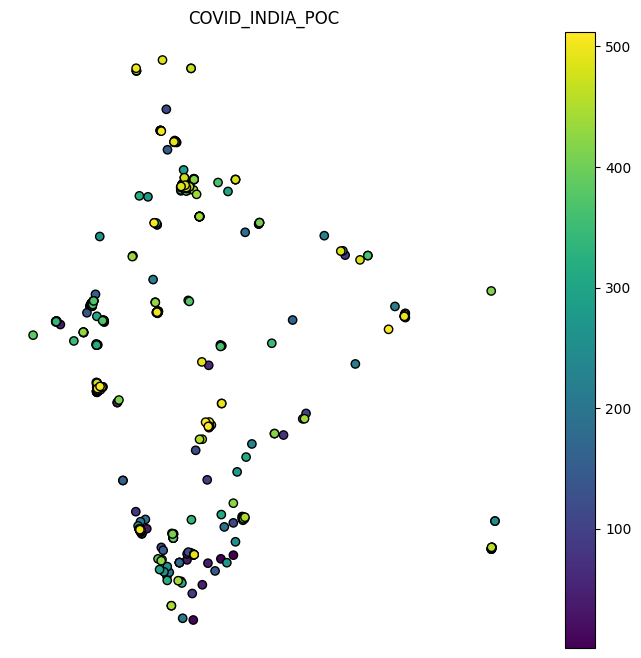

In [99]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(12, 8))
g_df.plot(
    ax=ax,
    column=g_df.columns[0],  # Cambia por la columna que quieras destacar
    cmap='viridis',
    edgecolor='black',
    legend=True
)
ax.set_title('COVID_INDIA_POC', fontsize=12)
ax.axis('off')
plt.show()


In [102]:
g_df.shape

(512, 8)

In [103]:
g_df.columns

Index(['OBJECTID', 'RecordID2', 'Address', 'State_UT', 'District', 'GC_LAT',
       'GC_LON', 'geometry'],
      dtype='object')

In [104]:
g_df.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

# 8. Archivos HTML y web scraping

HTML describe la estructura de una página mediante etiquetas y atributos. La extracción puede hacerse desde un archivo local o desde una URL, pero en ambos casos conviene separar tres tareas: descargar o abrir el documento, analizar su árbol y seleccionar los elementos que contienen los datos.

`BeautifulSoup` facilita la navegación del HTML. En sitios reales, los selectores pueden cambiar, existir contenido generado con JavaScript o aplicarse restricciones de uso; por eso hay que revisar los términos del sitio, limitar las solicitudes y comprobar que los datos extraídos sean completos.


In [105]:
# Leer un archivo HTML local
with open(ruta+'ejemplo.html', 'r', encoding='utf-8') as file:
    html_content = file.read()
print(html_content[:500])  # Muestra los primeros 500 caracteres

<html>
  <head>
    <title>Ejemplo de atributo Href</title>
  </head>
  <body>
    <h1>Ejemplo de atributo Href</h1>
    <p>
      <a href="https://www.python.org/">Documentación de python</a> es un enlace que te lleva a la página oficial de Python.
    </p>
  </body>
</html>



In [ ]:
#!pip install beautifulsoup4 #Instalar BeautifulSoup si es necesario

In [106]:
# Analizar HTML con BeautifulSoup
from bs4 import BeautifulSoup
soup = BeautifulSoup(html_content, 'html.parser')

# Extraer el título de la página
titulo = soup.title.string
print('Título de la página:', titulo)

Título de la página: Ejemplo de atributo Href


In [107]:
# Extraer los enlaces de la página
enlaces = soup.find_all('a')
print(enlaces)
for enlace in enlaces:
    print(enlace.get('href'))

[<a href="https://www.python.org/">Documentación de python</a>]
https://www.python.org/


In [108]:
#!pip install requests # Instalar requests si es necesario
import requests

url = 'https://www.python.org/'
response = requests.get(url)
web_html = response.text

# Analizar el HTML descargado
soup_web = BeautifulSoup(web_html, 'html.parser')


In [109]:
print(soup_web.title)

<title>Welcome to Python.org</title>


###### Ejemplo sencillo webscraping 

In [110]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
 
url = "https://codedamn-classrooms.github.io/webscraper-python-codedamn-classroom-website/"
response = requests.get(url)
soup = BeautifulSoup(response.text, "html.parser")
type(soup)

bs4.BeautifulSoup

In [111]:
#Obtener un dataframe con la información de los productos
products = []

for price_tag in soup.find_all("h4", string=lambda s: s and s.strip().startswith("$")):
    # El nombre del producto es la cadena que sigue después del tag <a> después del precio
    product_link = price_tag.find_next("a")
    if not product_link:
        continue
    product_name = product_link.text.strip()
    product_url = product_link["href"]
    # La descripción es el siguien tag <p> después de la liga del producto
    description_tag = product_link.find_next("p")
    description = description_tag.text.strip() if description_tag else ""
    # Los numero de reviews van después de <div> 
    reviews_tag = product_link.find_next(string=lambda s: s and "review" in s)
    try:
        reviews = int(reviews_tag.strip().split()[0])
    except Exception:
        reviews = None
    # Precio
    try:
        price = float(price_tag.text.strip().replace("$", ""))
    except Exception:
        price = None
 
    products.append({
        "Product Name": product_name,
        "Price": price,
        "Description": description,
        "Reviews": reviews,
        "Product URL": product_url
    })
 
df = pd.DataFrame(products)
df

,Product Name,Price,Description,Reviews,Product URL
0,Asus AsusPro Adv...,1139.54,Asus AsusPro Advanced BU401LA-FA271G Dark Grey...,7,/webscraper-python-codedamn-classroom-website/...
1,Asus ROG Strix G...,1101.83,"Apple MacBook Air 13.3"", Core i5 1.8GHz, 8GB, ...",4,/webscraper-python-codedamn-classroom-website/...
2,Acer Aspire 3 A3...,494.71,"Acer Aspire 3 A315-51 Black, 15.6"" FHD, Core\n...",2,/webscraper-python-codedamn-classroom-website/...


# 9. Archivos de imagen

Una imagen digital puede interpretarse como una matriz de píxeles. En una imagen RGB, la forma suele ser `(alto, ancho, 3)`: el último eje contiene los canales rojo, verde y azul. En imágenes con transparencia puede aparecer un cuarto canal alfa.

Leer una imagen como arreglo permite crear características numéricas, por ejemplo promedios de color, histogramas, bordes o texturas. Antes de modelar conviene revisar el rango de valores, el tipo de dato, la orientación y si todas las imágenes tienen la misma resolución.


Las imágenes RGB almacenan información de color en tres canales: Rojo (R), Verde (G) y Azul (B). Para leer y manipular imágenes en Python, se pueden usar las librerías:

| Librería | Ideal para | Lectura |
|---|---|---|
| **Pillow (PIL)** | manipulación general: abrir, convertir formatos, redimensionar, filtros simples | `Image.open()` |
| **imageio** | entrada/salida sencilla hacia `numpy` | `imageio.imread()` |
| **Matplotlib** | lectura rápida y **visualización** | `plt.imread()` / `plt.imshow()` |
| **OpenCV (cv2)** | visión por computadora, muy rápido, muchos algoritmos (¡usa orden **BGR**!) | `cv2.imread()` |
| **scikit-image (skimage)** | procesamiento científico: filtros, segmentación, umbralización | `skimage.io.imread()` |
| **scipy.ndimage** | filtros y transformaciones sobre arreglos n-dimensionales | opera sobre arreglos |

> **Idea clave:** casi todas devuelven un `ndarray`. Una vez en ese formato, se puede **escalar (resize)**, **recortar (crop)**, **limitar valores (clip)**, **filtrar (desenfoque/bordes)**, **rotar** y **umbralizar**.

En los siguientes ejemplos usaremos la imagen `Data/imagen.bmp` con cada librería.

En las celdas siguientes se observa la imagen completa, un canal individual y una versión en escala de grises. La conversión mediante el promedio es didáctica; para aplicaciones sensibles a la percepción humana suele ser preferible una transformación ponderada como la de luminancia.


In [112]:
# Configuración común para ejecutar esta sección de forma independiente
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

dir_base = os.getcwd()
print(dir_base)
ruta = os.path.join(dir_base, 'Data')
print(ruta)


C:\Users\uie70742\OneDrive - ITESO\ITESO\Maestría Ciencia de Datos\Ingeniería de Características\Ingenieria_Caracteristicas_O2026\Módulo 1 - Extracción de datos de diferentes fuentes
C:\Users\uie70742\OneDrive - ITESO\ITESO\Maestría Ciencia de Datos\Ingeniería de Características\Ingenieria_Caracteristicas_O2026\Módulo 1 - Extracción de datos de diferentes fuentes\Data


In [113]:
I=plt.imread(os.path.join(ruta,'imagen.bmp'))
I.shape

(199, 309, 4)

In [114]:
type(I)

numpy.ndarray

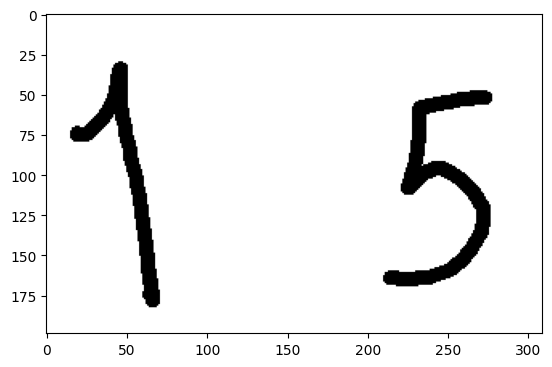

In [115]:
plt.imshow(I)

In [116]:
I[0,0,0] # pixel (0,0) de la matriz roja

np.uint8(255)

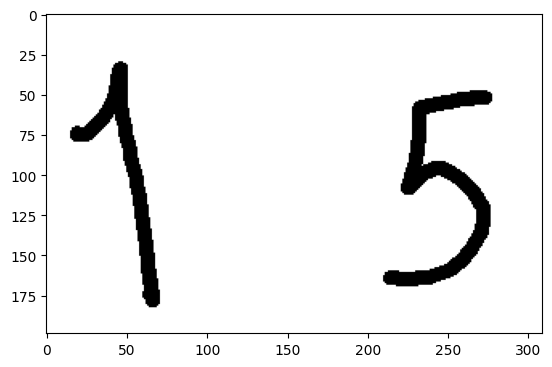

In [117]:
plt.imshow(I[:,:,0],cmap='gray') # Matriz roja

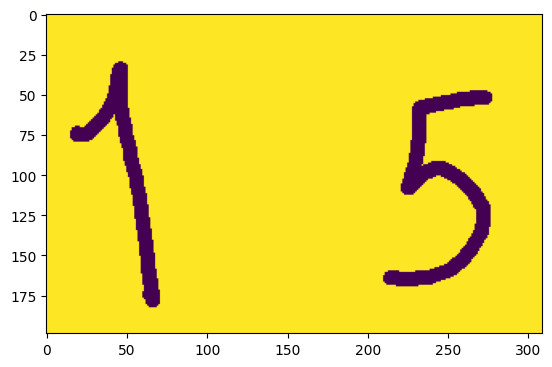

In [120]:
plt.imshow(I[:,:,2]) # Matriz roja

In [121]:
G=I.mean(axis=2)
G.shape

(199, 309)

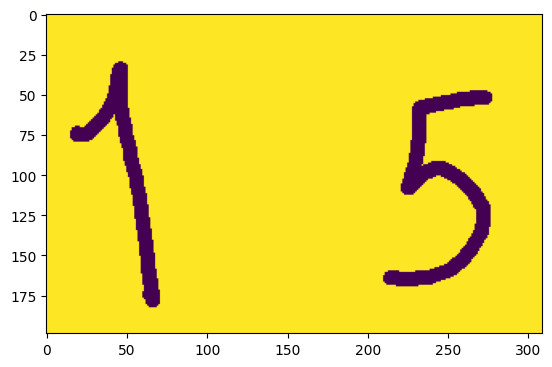

In [122]:
plt.imshow(G)

In [123]:
G[0,0]

np.float64(255.0)

#### 1) Pillow (PIL)

Pillow trabaja con objetos `Image`. Permite conocer tamaño y modo de color, convertir a arreglo de NumPy y aplicar transformaciones encadenadas.

In [124]:
from PIL import Image, ImageFilter

img = Image.open(os.path.join(ruta, 'imagen.bmp'))
print('Tamaño (ancho, alto):', img.size)
print('Modo de color       :', img.mode)

# Un objeto Image se convierte a arreglo de NumPy con np.array
arr = np.array(img)
print('Forma como arreglo  :', arr.shape)

Tamaño (ancho, alto): (309, 199)
Modo de color       : 1
Forma como arreglo  : (199, 309)


In [125]:
arr

array([[ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       ...,
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True]], shape=(199, 309))

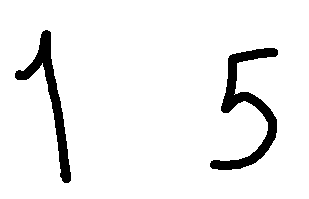

In [126]:
img

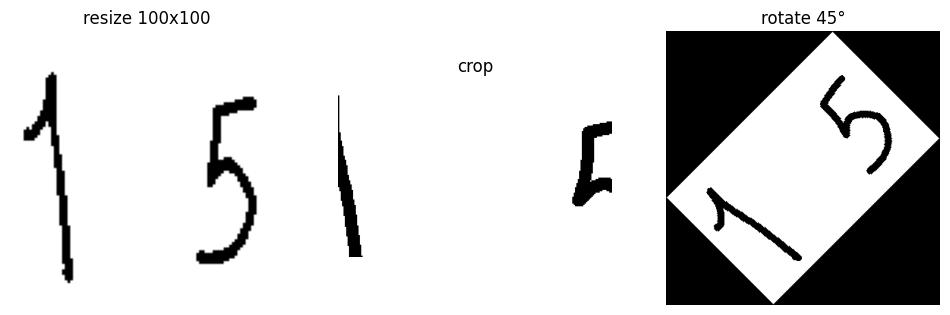

In [127]:
# Escalamiento (resize), recorte (crop) y rotación
img_pequena = img.resize((100, 100))        # forzar 100x100 px
img_recorte = img.crop((50, 20, 250, 150))  # (izq, arriba, der, abajo)
img_rotada  = img.rotate(45, expand=True)   # rotar 45°

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(img_pequena); ax[0].set_title('resize 100x100'); ax[0].axis('off')
ax[1].imshow(img_recorte); ax[1].set_title('crop');           ax[1].axis('off')
ax[2].imshow(img_rotada);  ax[2].set_title('rotate 45°');     ax[2].axis('off')
plt.show()

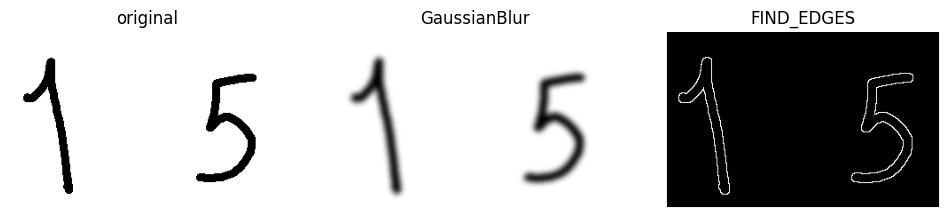

In [128]:
# Filtros integrados de Pillow: desenfoque y detección de bordes
img_rgb   = img.convert('RGB')
img_blur  = img_rgb.filter(ImageFilter.GaussianBlur(radius=3))
img_edges = img_rgb.filter(ImageFilter.FIND_EDGES)

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(img_rgb);   ax[0].set_title('original');     ax[0].axis('off')
ax[1].imshow(img_blur);  ax[1].set_title('GaussianBlur'); ax[1].axis('off')
ax[2].imshow(img_edges); ax[2].set_title('FIND_EDGES');   ax[2].axis('off')
plt.show()

#### 2) imageio: lectura directa a NumPy

`imageio` es la forma más simple de pasar una imagen a un arreglo (y de guardarla). Es el motor de lectura que usan otras librerías por debajo.

Tipo : <class 'numpy.ndarray'>
Forma: (199, 309) | dtype: bool


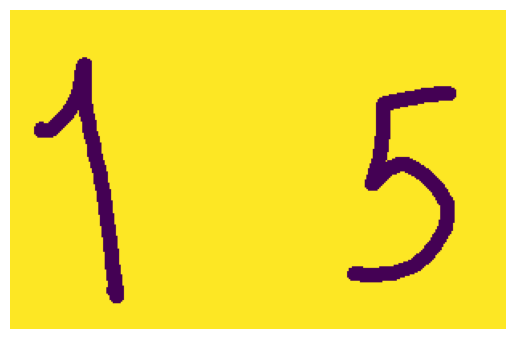

In [129]:
import imageio.v2 as imageio

img_arr = imageio.imread(os.path.join(ruta,'imagen.bmp'))
print('Tipo :', type(img_arr))
print('Forma:', img_arr.shape, '| dtype:', img_arr.dtype)
plt.imshow(img_arr); plt.axis('off'); plt.show()

#### 3) OpenCV (cv2)

OpenCV es el estándar en visión por computadora. Su única "trampa" es que lee los canales en orden **BGR** en vez de RGB, así que para visualizar con matplotlib hay que convertir con `cv2.cvtColor`.

Forma (alto, ancho, canales): (199, 309, 3)


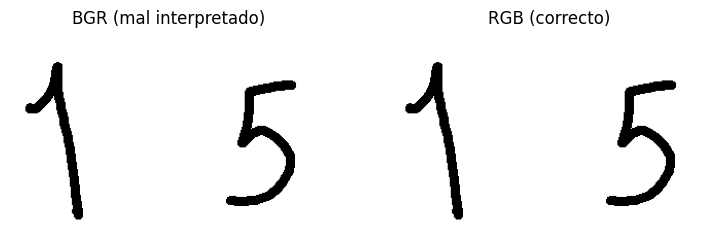

In [130]:
import cv2
import numpy as np

# cv2.imread falla con rutas que tienen acentos en Windows; leemos los bytes y decodificamos
img_bgr = cv2.imdecode(np.fromfile(os.path.join(ruta, 'imagen.bmp'), dtype=np.uint8), cv2.IMREAD_COLOR)
img_rgb_cv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
print('Forma (alto, ancho, canales):', img_bgr.shape)

fig, ax = plt.subplots(1, 2, figsize=(9, 4))
ax[0].imshow(img_bgr);    ax[0].set_title('BGR (mal interpretado)'); ax[0].axis('off')
ax[1].imshow(img_rgb_cv); ax[1].set_title('RGB (correcto)');         ax[1].axis('off')
plt.show()


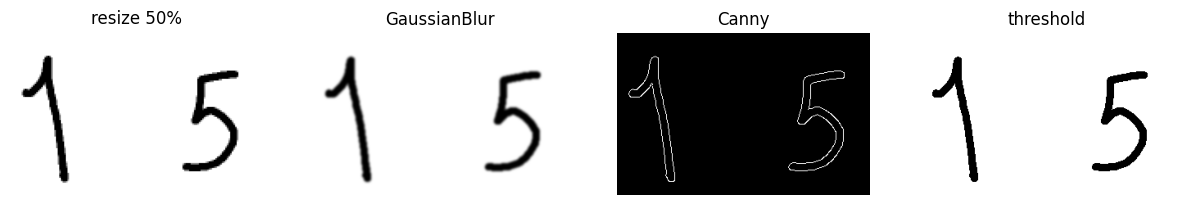

In [131]:
# Escalamiento, escala de grises, desenfoque, bordes (Canny) y umbralización
gris   = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
escala = cv2.resize(img_rgb_cv, None, fx=0.5, fy=0.5)      # reducir 50%
desenf = cv2.GaussianBlur(img_rgb_cv, (7, 7), 0)
bordes = cv2.Canny(gris, 100, 200)
_, umbral = cv2.threshold(gris, 127, 255, cv2.THRESH_BINARY)

fig, ax = plt.subplots(1, 4, figsize=(15, 4))
ax[0].imshow(escala);              ax[0].set_title('resize 50%');   ax[0].axis('off')
ax[1].imshow(desenf);              ax[1].set_title('GaussianBlur'); ax[1].axis('off')
ax[2].imshow(bordes, cmap='gray'); ax[2].set_title('Canny');        ax[2].axis('off')
ax[3].imshow(umbral, cmap='gray'); ax[3].set_title('threshold');    ax[3].axis('off')
plt.show()

#### 4) scikit-image

`skimage` está pensado para análisis y suele trabajar con imágenes en punto flotante (valores 0–1). Incluye filtros (Sobel, Gaussian), reescalado y **umbralización automática** con el método de Otsu.

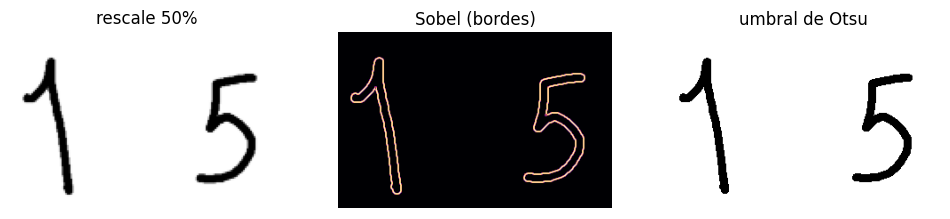

In [132]:
from skimage import io, color, filters, transform, util

img_sk = io.imread(os.path.join(ruta,'imagen.bmp'))
# imread puede devolver 2D (grises), 3 canales (RGB) o 4 (RGBA)
if img_sk.ndim == 2:
    gris_sk = util.img_as_float(img_sk)
else:
    gris_sk = color.rgb2gray(img_sk[:, :, :3])            # ignora el canal alfa

reescalada  = transform.rescale(gris_sk, 0.5)              # 50% del tamaño
sobel       = filters.sobel(gris_sk)                       # bordes (gradiente)
umbral_otsu = gris_sk > filters.threshold_otsu(gris_sk)    # binarización automática

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(reescalada, cmap='gray');  ax[0].set_title('rescale 50%');    ax[0].axis('off')
ax[1].imshow(sobel, cmap='magma');      ax[1].set_title('Sobel (bordes)'); ax[1].axis('off')
ax[2].imshow(umbral_otsu, cmap='gray'); ax[2].set_title('umbral de Otsu'); ax[2].axis('off')
plt.show()

#### 5) NumPy puro

Como la imagen es un arreglo, muchas operaciones no necesitan librerías extra. El **recorte** es *slicing*; el **clip** limita los valores a un rango (evita que se "desborden" al ajustar el brillo).

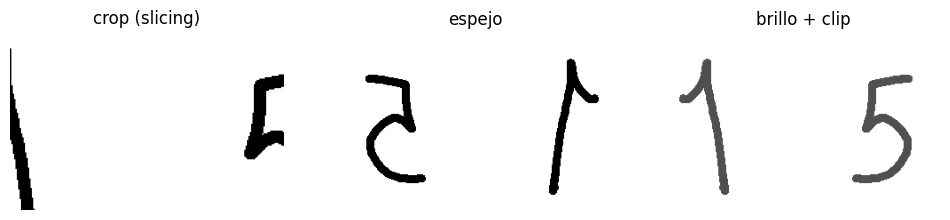

In [133]:
arr = np.array(img.convert('RGB'))

recorte  = arr[20:150, 50:250]                        # crop por slicing [filas, columnas]
volteada = arr[:, ::-1]                               # espejo horizontal
# Subir el brillo +80 y usar clip para no pasar de 255
brillo   = np.clip(arr.astype(int) + 80, 0, 255).astype(np.uint8)

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(recorte);  ax[0].set_title('crop (slicing)'); ax[0].axis('off')
ax[1].imshow(volteada); ax[1].set_title('espejo');         ax[1].axis('off')
ax[2].imshow(brillo);   ax[2].set_title('brillo + clip');  ax[2].axis('off')
plt.show()

#### 6) scipy.ndimage

`scipy.ndimage` aplica filtros y transformaciones geométricas directamente sobre el arreglo: rotación con interpolación, desenfoque gaussiano y filtro de **mediana** (muy útil para quitar ruido tipo "sal y pimienta").

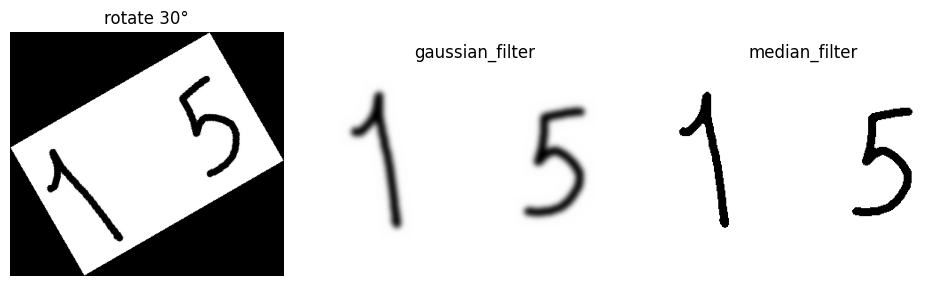

In [134]:
from scipy import ndimage

gris_np = np.array(img.convert('L'))               # 'L' = escala de grises

rotada    = ndimage.rotate(gris_np, 30, reshape=True)
suavizada = ndimage.gaussian_filter(gris_np, sigma=3)
mediana   = ndimage.median_filter(gris_np, size=5)

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(rotada, cmap='gray');    ax[0].set_title('rotate 30°');      ax[0].axis('off')
ax[1].imshow(suavizada, cmap='gray'); ax[1].set_title('gaussian_filter'); ax[1].axis('off')
ax[2].imshow(mediana, cmap='gray');   ax[2].set_title('median_filter');   ax[2].axis('off')
plt.show()

##### Guardar el resultado

Todas las librerías pueden **escribir** imágenes: `img.save(...)` en Pillow, `cv2.imwrite(...)`, `imageio.imwrite(...)` o `plt.imsave(...)`. Así se persiste el resultado de un pipeline de procesamiento.

In [135]:
# Guardar una versión procesada (Pillow)
img_blur.save(ruta + 'imagen_procesada.png')
print('Imagen guardada en:', ruta + 'imagen_procesada.png')

Imagen guardada en: C:\Users\uie70742\OneDrive - ITESO\ITESO\Maestría Ciencia de Datos\Ingeniería de Características\Ingenieria_Caracteristicas_O2026\Módulo 1 - Extracción de datos de diferentes fuentes\Dataimagen_procesada.png


###  Operaciones con imágenes

Como una imagen es un arreglo, se pueden aplicar **operaciones aritméticas y lógicas** píxel a píxel: sumar/restar (brillo), multiplicar (contraste), mezclar dos imágenes, invertir colores (negativo) o aplicar máscaras. **NumPy** y **OpenCV** son las mejores opciones porque operan de forma vectorizada sobre el arreglo.

> **Cuidado con el desbordamiento:** en `uint8` los valores van de 0 a 255. Si sumas y superas 255, el valor "da la vuelta". Por eso se usa `np.clip` o funciones de OpenCV como `cv2.add` / `cv2.addWeighted`, que **saturan** en el límite.

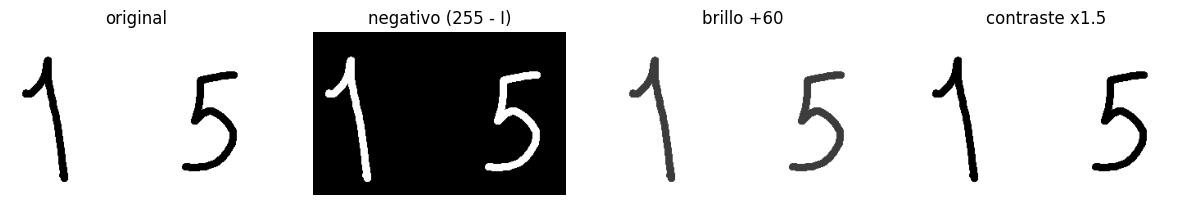

In [136]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

img_rgb = np.array(Image.open(os.path.join(ruta,'imagen.bmp')).convert('RGB'))

negativo   = 255 - img_rgb                                          # invertir colores
mas_brillo = np.clip(img_rgb.astype(int) + 60, 0, 255).astype(np.uint8)
contraste  = np.clip(img_rgb.astype(int) * 1.5, 0, 255).astype(np.uint8)   # x1.5

fig, ax = plt.subplots(1, 4, figsize=(15, 4))
for a, im, t in zip(ax, [img_rgb, negativo, mas_brillo, contraste],
                    ['original', 'negativo (255 - I)', 'brillo +60', 'contraste x1.5']):
    a.imshow(im); a.set_title(t); a.axis('off')
plt.show()

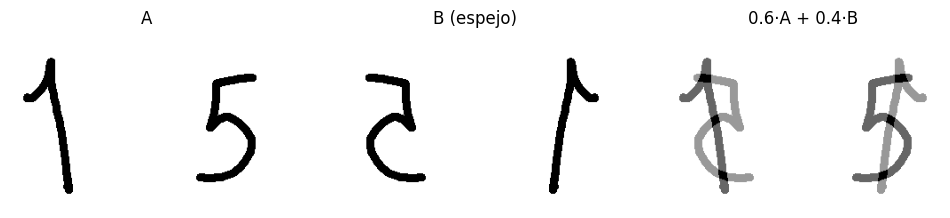

In [137]:
import cv2

# Mezcla ponderada de dos imágenes (blending): alpha*A + beta*B
volteada = np.ascontiguousarray(img_rgb[:, ::-1])            # segunda "imagen": espejo
mezcla = cv2.addWeighted(img_rgb, 0.6, volteada, 0.4, 0)

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(img_rgb);  ax[0].set_title('A');              ax[0].axis('off')
ax[1].imshow(volteada); ax[1].set_title('B (espejo)');     ax[1].axis('off')
ax[2].imshow(mezcla);   ax[2].set_title('0.6·A + 0.4·B');  ax[2].axis('off')
plt.show()

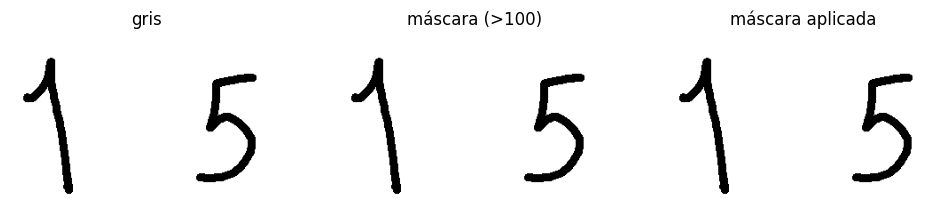

In [138]:
# Operación lógica con máscara: conservar solo los píxeles brillantes
gris = np.array(Image.open(os.path.join(ruta, 'imagen.bmp')).convert('L'))
mascara = gris > 100                                # True donde es brillante

resultado = img_rgb.copy()
resultado[~mascara] = 0                             # apagar el resto

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(gris, cmap='gray');    ax[0].set_title('gris');            ax[0].axis('off')
ax[1].imshow(mascara, cmap='gray'); ax[1].set_title('máscara (>100)');  ax[1].axis('off')
ax[2].imshow(resultado);            ax[2].set_title('máscara aplicada');ax[2].axis('off')
plt.show()

###  Reescalamiento

Reescalar tiene dos sentidos:

1. **Reescalamiento geométrico (resampling):** cambiar el **tamaño** de la imagen. Al ampliar o reducir hay que **interpolar** los píxeles; el método (vecino más cercano, bilineal, bicúbico) afecta la calidad.
2. **Reescalamiento de intensidad (normalización):** cambiar el **rango de valores** de los píxeles, por ejemplo de `[0, 255]` a `[0, 1]`, o estirar el contraste. Es un paso habitual antes de entrenar modelos.

`OpenCV` es ideal para el resampling con distintas interpolaciones y `scikit-image` (`transform` y `exposure`) para ambos casos.

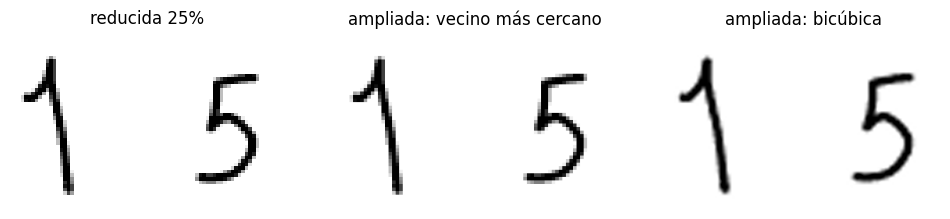

In [139]:
# Reescalamiento geométrico: reducir y volver a ampliar para comparar interpolaciones
img_rgb = np.array(Image.open(os.path.join(ruta, 'imagen.bmp')).convert('RGB'))
alto, ancho = img_rgb.shape[:2]

pequena  = cv2.resize(img_rgb, None, fx=0.25, fy=0.25, interpolation=cv2.INTER_AREA)
vecino   = cv2.resize(pequena, (ancho, alto), interpolation=cv2.INTER_NEAREST)
bicubica = cv2.resize(pequena, (ancho, alto), interpolation=cv2.INTER_CUBIC)

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(pequena);  ax[0].set_title('reducida 25%');                ax[0].axis('off')
ax[1].imshow(vecino);   ax[1].set_title('ampliada: vecino más cercano');ax[1].axis('off')
ax[2].imshow(bicubica); ax[2].set_title('ampliada: bicúbica');          ax[2].axis('off')
plt.show()

Original: (199, 309, 3)
resize  : (120, 200, 3)
rescale : (100, 154, 3)


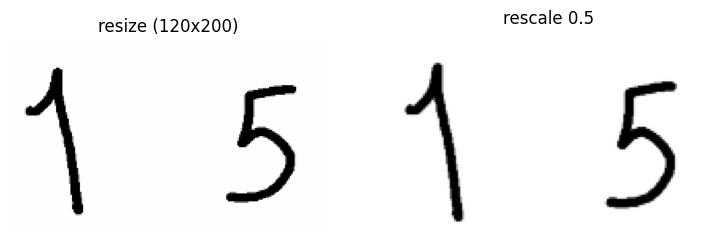

In [140]:
from skimage import transform

# resize a un tamaño exacto; rescale por factor
redim  = transform.resize(img_rgb, (120, 200))               # (alto, ancho)
factor = transform.rescale(img_rgb, 0.5, channel_axis=2)      # 50% en alto y ancho

print('Original:', img_rgb.shape)
print('resize  :', redim.shape)
print('rescale :', factor.shape)

fig, ax = plt.subplots(1, 2, figsize=(9, 4))
ax[0].imshow(redim);  ax[0].set_title('resize (120x200)'); ax[0].axis('off')
ax[1].imshow(factor); ax[1].set_title('rescale 0.5');      ax[1].axis('off')
plt.show()

Rango original   : [0, 255]
Rango normalizado: [0.00, 1.00]


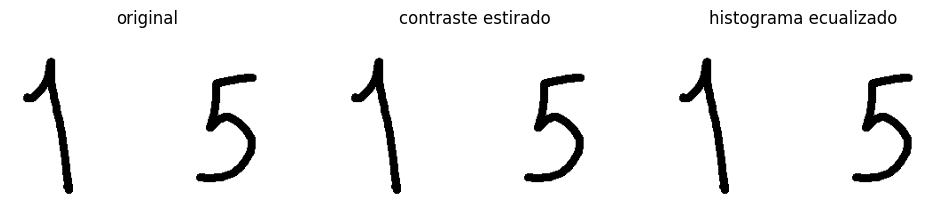

In [141]:
from skimage import exposure

# Reescalamiento de intensidad: normalización min-max, estiramiento y ecualización
gris = np.array(Image.open(os.path.join(ruta, 'imagen.bmp')).convert('L'))

normalizada = (gris - gris.min()) / (gris.max() - gris.min())   # a rango [0, 1]
print('Rango original   : [%d, %d]' % (gris.min(), gris.max()))
print('Rango normalizado: [%.2f, %.2f]' % (normalizada.min(), normalizada.max()))

p2, p98 = np.percentile(gris, (2, 98))
estirada   = exposure.rescale_intensity(gris, in_range=(p2, p98))  # estirar contraste
ecualizada = exposure.equalize_hist(gris)                          # ecualizar histograma

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(gris, cmap='gray');       ax[0].set_title('original');            ax[0].axis('off')
ax[1].imshow(estirada, cmap='gray');   ax[1].set_title('contraste estirado');  ax[1].axis('off')
ax[2].imshow(ecualizada, cmap='gray'); ax[2].set_title('histograma ecualizado');ax[2].axis('off')
plt.show()

# 10. Aplicaciones en Ciencias de Datos

La fuente determina qué información puede conservarse y qué transformaciones serán necesarias. La siguiente guía conecta cada formato con tareas frecuentes de análisis y ayuda a elegir una primera estrategia de extracción.

```mermaid
flowchart TD
    Q{¿Cómo está organizada la fuente?}
    Q -->|Filas y columnas| T[CSV o Excel]
    Q -->|Texto libre| X[Texto y regex]
    Q -->|Objetos anidados| J[JSON o XML]
    Q -->|Geometría y atributos| S[Shapefile]
    Q -->|Etiquetas de una página| H[HTML]
    Q -->|Píxeles| I[Imagen]
    T --> R[DataFrame]
    X --> R
    J --> R
    S --> R
    H --> R
    I --> M[Matriz o características]
```


## Archivos de texto

Son adecuados cuando la señal principal está en el lenguaje. Después de extraer el contenido, una canalización típica incluye normalización, tokenización, eliminación o conservación consciente de palabras vacías y generación de características. Las regex funcionan bien para patrones concretos, pero no sustituyen un análisis lingüístico completo.

> **Aplicaciones:** análisis de sentimientos, extracción de palabras clave, procesamiento de lenguaje natural y análisis de logs para detectar patrones o anomalías.


### Archivos Excel y CSV

Son una buena entrada para análisis exploratorio y preparación de datos porque ya expresan observaciones en filas y variables en columnas. La extracción debe ir acompañada de validaciones de tipos, duplicados, valores faltantes y unidades.

> **Aplicaciones:** agrupar ventas por producto, preparar características para modelos de machine learning y generar reportes mensuales de ingresos.


### Archivos de imágenes RGB

La imagen se convierte en variables numéricas antes de entrenar un modelo. Además de los canales de color, pueden extraerse histogramas, bordes, texturas o representaciones aprendidas por redes convolucionales.

> **Aplicaciones:** clasificar dígitos escritos a mano, detectar regiones anómalas en imágenes médicas y calcular histogramas de color.


### Archivos XML

> **Integración de datos de sistemas empresariales:**
  - Extraer información de clientes de un archivo XML exportado de un ERP.
    
> **Procesamiento de datos de sensores o dispositivos IoT:**
  - Leer registros de temperatura almacenados en XML.
    
> **Análisis de datos de publicaciones científicas:**
  - Obtener títulos y autores de artículos en formato XML

### Archivos JSON

> **Consumo de APIs web:**
  - Obtener y analizar tweets desde la API de Twitter.
    
> **Almacenamiento y análisis de logs:**
  - Procesar registros de acceso de una aplicación web.
    
> **Análisis de datos de aplicaciones móviles:**
  - Leer resultados de encuestas exportadas en JSON.

### Archivos Shapefile (SHP)

> **Análisis geoespacial:**
  - Calcular la distancia entre puntos de interés en una ciudad.
    
> **Estudios ambientales y urbanos:**
  - Analizar la distribución de áreas verdes en una zona urbana.

> **Modelado de redes y transporte:**
  - Determinar rutas óptimas entre dos ubicaciones.

## Archivos HTML:
> **Web scraping:** Extraer datos estructurados de páginas web para análisis posterior.

> **Construcción de datasets:** Recolectar información de múltiples páginas HTML para crear conjuntos de datos.

> **Análisis de enlaces:** Estudiar la estructura de enlaces en sitios web para análisis de redes.

> **Extracción de tablas:** Obtener datos tabulares de páginas HTML para análisis estadístico.